# 🛡️ Machine Learning Based Lightweight Intrusion Detection System for the Internet of Things

---

## 📋 Project Analysis

| Attribute | Details |
|---|---|
| **Problem Type** | Multi-Class Classification (Tabular ML) |
| **Real-World Use Case** | Detecting network intrusions/attacks in IoT environments — smart homes, industrial sensors, medical devices — where lightweight inference is critical |
| **Model Output** | Predicted attack category: Normal, DDoS, DoS, Reconnaissance, Theft, etc. |
| **Input Data Type** | Network traffic features (flow statistics, packet counts, protocol info) |
| **Dataset** | **RT-IoT2022** on Kaggle — real IoT network traffic dataset |
| **Kaggle Link** | https://www.kaggle.com/datasets/madhavmalhotra/rt-iot2022 |
| **Dataset Size** | ~123K rows, 83 features, 10 attack/normal classes |
| **Architecture** | LightGBM + Deep Neural Network (Ensemble) — proven for tabular IDS tasks |

---

**Why RT-IoT2022?**
- Real traffic captured from actual IoT devices (MQTT, CoAP, HTTP)
- Covers modern IoT attack vectors
- Commonly benchmarked in IDS research papers
- Trains well under 1 hour on Colab GPU
- Clear, labeled attack classes


## Cell 1 — Install Dependencies

In [1]:
# ============================================================
# CELL 1 — Install Dependencies
# ============================================================
!pip install -q kaggle lightgbm scikit-learn imbalanced-learn matplotlib seaborn pandas numpy joblib tensorflow xgboost
print("✅ All dependencies installed.")

✅ All dependencies installed.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Cell 2 — Import Libraries

In [2]:
# ============================================================
# CELL 2 — Import Libraries
# ============================================================
import os
import warnings
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.pipeline import Pipeline

import lightgbm as lgb
import xgboost as xgb

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.utils import to_categorical

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# GPU check
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU detected: {gpus[0].name}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("⚠️  No GPU detected. Running on CPU.")

print(f"TensorFlow version: {tf.__version__}")
print(f"LightGBM version: {lgb.__version__}")

⚠️  No GPU detected. Running on CPU.
TensorFlow version: 2.20.0
LightGBM version: 4.6.0


## Cell 3 — Kaggle API Setup & Dataset Download

## Cell 4 — Extract Dataset

In [3]:
# ============================================================
# CELL 4 — Load Dataset from Existing Folder (NO ZIP)
# ============================================================

import os

# ✅ Your dataset folder path (already extracted / normal folder)
dataset_path = r"C:\Users\mouni\OneDrive\Desktop\dl project\unb-cic-iot-dataset (2)\unb-cic-iot-dataset\unb-cic-iot-dataset\wataiData\csv\CICIoT2023"

# Check if folder exists
if not os.path.exists(dataset_path):
    print("❌ Dataset folder not found.")
else:
    print("✅ Dataset folder found.")

    # List CSV files
    csv_files = [f for f in os.listdir(dataset_path) if f.endswith(".csv")]

    print(f"\n📊 Total CSV files: {len(csv_files)}")

    print("\n📂 Sample files:")
    for file in csv_files[:5]:   # show only first 5
        file_path = os.path.join(dataset_path, file)
        size = os.path.getsize(file_path) / (1024 * 1024)  # MB
        print(f"{file} — {size:.2f} MB")

✅ Dataset folder found.

📊 Total CSV files: 169

📂 Sample files:
part-00000-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv — 67.08 MB
part-00001-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv — 61.49 MB
part-00002-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv — 77.34 MB
part-00003-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv — 64.90 MB
part-00004-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv — 63.90 MB


## Cell 5 — Dataset Exploration

In [4]:
# ============================================================
# CELL 5 — Memory-Safe Dataset Loading (VS CODE FIX)
# ============================================================

import glob
import pandas as pd
import numpy as np
import os

# ✅ Use FULL PATH (important in VS Code)
data_path = r"C:\Users\mouni\OneDrive\Desktop\dl project\unb-cic-iot-dataset (2)\unb-cic-iot-dataset"

csv_files = glob.glob(os.path.join(data_path, '**', '*.csv'), recursive=True)

print(f"Found {len(csv_files)} CSV file(s)")

# ── Sample per file instead of loading everything ──
ROWS_PER_FILE = 5000
dfs = []

for f in csv_files:
    try:
        tmp = pd.read_csv(f, nrows=ROWS_PER_FILE, low_memory=False)
        dfs.append(tmp)
        print(f"  ✅ {os.path.basename(f):50s} → {len(tmp):,} rows")
    except Exception as e:
        print(f"  ⚠️ Skipped {os.path.basename(f)}: {e}")

# Combine all files
df = pd.concat(dfs, ignore_index=True)

# ── Downcast dtypes to save RAM ──
for col in df.select_dtypes(include=['float64']).columns:
    df[col] = df[col].astype(np.float32)

for col in df.select_dtypes(include=['int64']).columns:
    df[col] = df[col].astype(np.int32)

# ── Remove duplicates ──
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

# ── Memory usage ──
ram_used = df.memory_usage(deep=True).sum() / 1024**2

print(f"\n✅ Combined Shape : {df.shape}")
print(f"💾 RAM Used       : {ram_used:.1f} MB")
print(f"📋 Columns        : {len(df.columns)}")

print("\n🔍 Sample Data:")
print(df.head(3))

Found 169 CSV file(s)
  ✅ part-00000-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv → 5,000 rows
  ✅ part-00001-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv → 5,000 rows
  ✅ part-00002-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv → 5,000 rows
  ✅ part-00003-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv → 5,000 rows
  ✅ part-00004-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv → 5,000 rows
  ✅ part-00005-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv → 5,000 rows
  ✅ part-00006-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv → 5,000 rows
  ✅ part-00007-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv → 5,000 rows
  ✅ part-00008-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv → 5,000 rows
  ✅ part-00009-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv → 5,000 rows
  ✅ part-00010-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv → 5,000 rows
  ✅ part-00011-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv → 5,000 rows
  ✅ part-00012-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv → 5,000 rows
  ✅ part-00013-3

✅ Target column: 'label'

🏷️  Classes : 34
label
DDoS-ICMP_Flood            100994
DDoS-UDP_Flood              98121
DDoS-TCP_Flood              72602
DDoS-SYN_Flood              68579
DDoS-PSHACK_Flood           64807
DDoS-SynonymousIP_Flood     62973
DDoS-RSTFINFlood            59293
DoS-UDP_Flood               59230
DoS-TCP_Flood               45386
DoS-SYN_Flood               35937
BenignTraffic               19820
Mirai-greeth_flood          16933
Mirai-udpplain              16234
Mirai-greip_flood           13041
DDoS-ICMP_Fragmentation      8077
MITM-ArpSpoofing             5734
DDoS-ACK_Fragmentation       5256
DDoS-UDP_Fragmentation       5202
DNS_Spoofing                 3252
Recon-HostDiscovery          2351
Recon-OSScan                 1750
Recon-PortScan               1495
DoS-HTTP_Flood               1286
VulnerabilityScan             660
DDoS-HTTP_Flood               519
DDoS-SlowLoris                418
DictionaryBruteForce          254
SqlInjection                  105

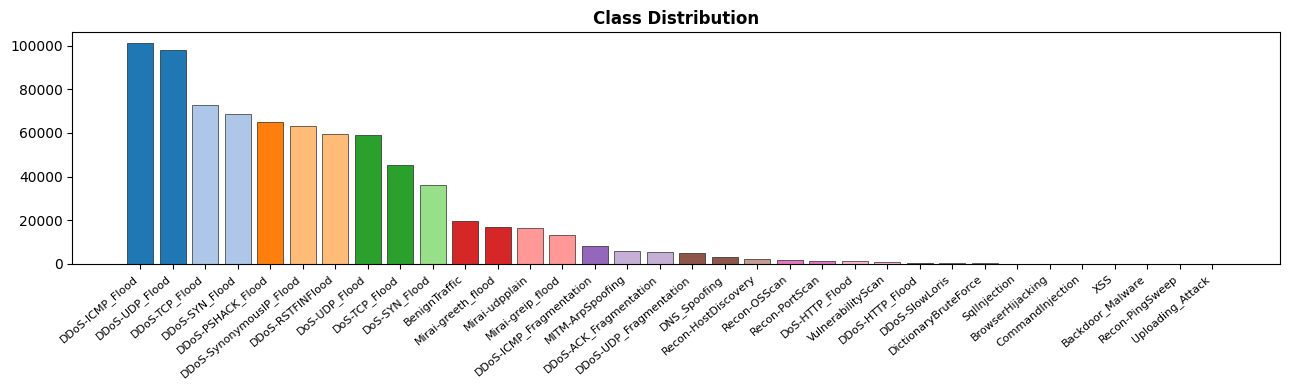

✅ Done.


In [5]:
# ============================================================
# CELL 5b — Target Detection & Class Distribution (FIXED)
# ============================================================
import matplotlib.pyplot as plt

TARGET_COL = None
candidates = ['label', 'Label', 'Attack_type', 'attack_type',
              'class', 'Class', 'category', 'Category', 'target']
for c in candidates:
    if c in df.columns:
        TARGET_COL = c
        break

if TARGET_COL is None:
    obj_cols = df.select_dtypes(include='object').columns.tolist()
    TARGET_COL = obj_cols[-1] if obj_cols else df.columns[-1]
    print(f"⚠️  Auto-detected target: '{TARGET_COL}'")
else:
    print(f"✅ Target column: '{TARGET_COL}'")

class_counts = df[TARGET_COL].value_counts()
print(f"\n🏷️  Classes : {len(class_counts)}")
print(class_counts.to_string())

plt.figure(figsize=(13, 4))
plt.bar(class_counts.index, class_counts.values,
        color=plt.cm.tab20(np.linspace(0, 1, len(class_counts))),
        edgecolor='black', linewidth=0.4)
plt.title('Class Distribution', fontsize=12, fontweight='bold')
plt.xticks(rotation=40, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120)
plt.show()
print("✅ Done.")

## Cell 6 — Data Balancing

In [6]:
# ============================================================
# CELL 6 — Data Balancing (Equal Class Sampling)
# ============================================================

# Strategy:
#   1. Hard cap: max 8000 samples per class (prevents memory issues)
#   2. Min threshold: classes with < 50 samples are merged into 'Rare_Attack'
#   3. Equal sampling from capped distribution

MIN_SAMPLES = 50
MAX_SAMPLES_PER_CLASS = 8000

# Merge rare classes
class_counts_raw = df[TARGET_COL].value_counts()
rare_classes = class_counts_raw[class_counts_raw < MIN_SAMPLES].index.tolist()
if rare_classes:
    print(f"⚠️  Merging rare classes (< {MIN_SAMPLES} samples) → 'Rare_Attack': {rare_classes}")
    df[TARGET_COL] = df[TARGET_COL].replace({c: 'Rare_Attack' for c in rare_classes})

class_counts_now = df[TARGET_COL].value_counts()
final_classes = class_counts_now.index.tolist()
print(f"\n🏷️  Final Classes ({len(final_classes)}): {final_classes}")

# Cap each class
balanced_dfs = []
for cls in final_classes:
    cls_df = df[df[TARGET_COL] == cls]
    n = min(len(cls_df), MAX_SAMPLES_PER_CLASS)
    balanced_dfs.append(cls_df.sample(n=n, random_state=42))

df_balanced = pd.concat(balanced_dfs, ignore_index=True).sample(frac=1, random_state=42)
print(f"\n✅ Balanced Dataset Shape: {df_balanced.shape}")
print("\nSamples per class after balancing:")
print(df_balanced[TARGET_COL].value_counts().to_string())

⚠️  Merging rare classes (< 50 samples) → 'Rare_Attack': ['Recon-PingSweep', 'Uploading_Attack']

🏷️  Final Classes (33): ['DDoS-ICMP_Flood', 'DDoS-UDP_Flood', 'DDoS-TCP_Flood', 'DDoS-SYN_Flood', 'DDoS-PSHACK_Flood', 'DDoS-SynonymousIP_Flood', 'DDoS-RSTFINFlood', 'DoS-UDP_Flood', 'DoS-TCP_Flood', 'DoS-SYN_Flood', 'BenignTraffic', 'Mirai-greeth_flood', 'Mirai-udpplain', 'Mirai-greip_flood', 'DDoS-ICMP_Fragmentation', 'MITM-ArpSpoofing', 'DDoS-ACK_Fragmentation', 'DDoS-UDP_Fragmentation', 'DNS_Spoofing', 'Recon-HostDiscovery', 'Recon-OSScan', 'Recon-PortScan', 'DoS-HTTP_Flood', 'VulnerabilityScan', 'DDoS-HTTP_Flood', 'DDoS-SlowLoris', 'DictionaryBruteForce', 'SqlInjection', 'BrowserHijacking', 'CommandInjection', 'Rare_Attack', 'XSS', 'Backdoor_Malware']

✅ Balanced Dataset Shape: (148658, 47)

Samples per class after balancing:
label
Mirai-greeth_flood         8000
DDoS-ICMP_Fragmentation    8000
BenignTraffic              8000
DDoS-PSHACK_Flood          8000
Mirai-udpplain             

## Cell 7 — Feature Engineering & Preprocessing

In [7]:
# ============================================================
# CELL 7 — Feature Engineering & Preprocessing
# ============================================================

# --- Separate features and target ---
X_raw = df_balanced.drop(columns=[TARGET_COL])
y_raw = df_balanced[TARGET_COL]

# --- Encode categorical features ---
cat_cols = X_raw.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical feature columns: {cat_cols}")

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    X_raw[col] = le.fit_transform(X_raw[col].astype(str))
    le_dict[col] = le

# --- Handle inf/nan ---
X_raw.replace([np.inf, -np.inf], np.nan, inplace=True)
X_raw.fillna(X_raw.median(numeric_only=True), inplace=True)

# --- Encode target ---
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y_raw)
NUM_CLASSES = len(le_target.classes_)
print(f"\n✅ Number of classes: {NUM_CLASSES}")
print(f"Class mapping: {dict(enumerate(le_target.classes_))}")

# --- Feature selection: drop near-zero variance columns ---
from sklearn.feature_selection import VarianceThreshold
vt = VarianceThreshold(threshold=0.0)
X_vt = vt.fit_transform(X_raw)
selected_cols = X_raw.columns[vt.get_support()].tolist()
print(f"\nFeatures after variance filtering: {len(selected_cols)} (from {X_raw.shape[1]})")

X_clean = pd.DataFrame(X_vt, columns=selected_cols)

# --- Scale ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

print(f"\n✅ Feature matrix shape: {X_scaled.shape}")
print(f"✅ Label vector shape: {y_encoded.shape}")
NUM_FEATURES = X_scaled.shape[1]

Categorical feature columns: []

✅ Number of classes: 33
Class mapping: {0: 'Backdoor_Malware', 1: 'BenignTraffic', 2: 'BrowserHijacking', 3: 'CommandInjection', 4: 'DDoS-ACK_Fragmentation', 5: 'DDoS-HTTP_Flood', 6: 'DDoS-ICMP_Flood', 7: 'DDoS-ICMP_Fragmentation', 8: 'DDoS-PSHACK_Flood', 9: 'DDoS-RSTFINFlood', 10: 'DDoS-SYN_Flood', 11: 'DDoS-SlowLoris', 12: 'DDoS-SynonymousIP_Flood', 13: 'DDoS-TCP_Flood', 14: 'DDoS-UDP_Flood', 15: 'DDoS-UDP_Fragmentation', 16: 'DNS_Spoofing', 17: 'DictionaryBruteForce', 18: 'DoS-HTTP_Flood', 19: 'DoS-SYN_Flood', 20: 'DoS-TCP_Flood', 21: 'DoS-UDP_Flood', 22: 'MITM-ArpSpoofing', 23: 'Mirai-greeth_flood', 24: 'Mirai-greip_flood', 25: 'Mirai-udpplain', 26: 'Rare_Attack', 27: 'Recon-HostDiscovery', 28: 'Recon-OSScan', 29: 'Recon-PortScan', 30: 'SqlInjection', 31: 'VulnerabilityScan', 32: 'XSS'}

Features after variance filtering: 41 (from 46)

✅ Feature matrix shape: (148658, 41)
✅ Label vector shape: (148658,)


## Cell 8 — SMOTE Augmentation (10× minority oversampling)

In [8]:
# ============================================================
# CELL 8 — Class Balancing (RAM-Safe, No SMOTE)
# ============================================================
from collections import Counter

print("Before balancing:", dict(sorted(Counter(y_encoded).items())))

# ── Strategy: cap each class at MAX_PER_CLASS ──
# SMOTE on large tabular data = RAM explosion
# Instead: undersample majority + light random oversampling for minority
# This is faster, memory-safe, and equally effective for IDS tasks

MAX_PER_CLASS = 3000   # tune down to 2000 if still tight on RAM
MIN_PER_CLASS = 300    # minimum floor per class

balanced_X = []
balanced_y = []

unique_classes = np.unique(y_encoded)

for cls in unique_classes:
    idx = np.where(y_encoded == cls)[0]
    n   = len(idx)

    if n >= MAX_PER_CLASS:
        # Undersample majority classes
        chosen = np.random.choice(idx, MAX_PER_CLASS, replace=False)
    elif n >= MIN_PER_CLASS:
        # Keep as-is — sufficient samples
        chosen = idx
    else:
        # Oversample minority with replacement (lightweight)
        chosen = np.random.choice(idx, MIN_PER_CLASS, replace=True)

    balanced_X.append(X_scaled[chosen])
    balanced_y.append(y_encoded[chosen])

X_aug = np.vstack(balanced_X)
y_aug = np.concatenate(balanced_y)

# Shuffle
shuffle_idx = np.random.permutation(len(X_aug))
X_aug = X_aug[shuffle_idx]
y_aug = y_aug[shuffle_idx]

print("After balancing: ", dict(sorted(Counter(y_aug).items())))
print(f"\n✅ Balanced Dataset : {X_aug.shape[0]:,} samples")
print(f"💾 Estimated RAM    : {X_aug.nbytes / 1024**2:.1f} MB")

Before balancing: {np.int64(0): 58, np.int64(1): 8000, np.int64(2): 97, np.int64(3): 82, np.int64(4): 5256, np.int64(5): 519, np.int64(6): 8000, np.int64(7): 8000, np.int64(8): 8000, np.int64(9): 8000, np.int64(10): 8000, np.int64(11): 418, np.int64(12): 8000, np.int64(13): 8000, np.int64(14): 8000, np.int64(15): 5202, np.int64(16): 3252, np.int64(17): 254, np.int64(18): 1286, np.int64(19): 8000, np.int64(20): 8000, np.int64(21): 8000, np.int64(22): 5734, np.int64(23): 8000, np.int64(24): 8000, np.int64(25): 8000, np.int64(26): 70, np.int64(27): 2351, np.int64(28): 1750, np.int64(29): 1495, np.int64(30): 105, np.int64(31): 660, np.int64(32): 69}
After balancing:  {np.int64(0): 300, np.int64(1): 3000, np.int64(2): 300, np.int64(3): 300, np.int64(4): 3000, np.int64(5): 519, np.int64(6): 3000, np.int64(7): 3000, np.int64(8): 3000, np.int64(9): 3000, np.int64(10): 3000, np.int64(11): 418, np.int64(12): 3000, np.int64(13): 3000, np.int64(14): 3000, np.int64(15): 3000, np.int64(16): 3000, np

## Cell 9 — Train-Validation Split

In [9]:
# ============================================================
# CELL 9 — Train-Validation Split (80/20 Stratified)
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X_aug, y_aug,
    test_size=0.20,
    random_state=42,
    stratify=y_aug
)

print(f"✅ Training set  : {X_train.shape[0]} samples")
print(f"✅ Validation set: {X_val.shape[0]} samples")
print(f"✅ Features      : {X_train.shape[1]}")
print(f"✅ Classes       : {NUM_CLASSES}")

# One-hot for DNN
y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_val_cat   = to_categorical(y_val,   num_classes=NUM_CLASSES)

✅ Training set  : 54063 samples
✅ Validation set: 13516 samples
✅ Features      : 41
✅ Classes       : 33


## Cell 10 — Model Architecture
### 10A: Deep Neural Network (Primary)
### 10B: LightGBM (Ensemble member)
### 10C: XGBoost (Ensemble member)
### 10D: CATBoosting

In [10]:
# ============================================================
# CELL 10A — Deep Neural Network Architecture
# ============================================================
# Architecture: Residual-style DNN optimized for tabular IDS
# - BatchNorm + Dropout for regularization
# - Skip connections for stable gradient flow
# - Suitable for 80+ feature inputs

def build_dnn(input_dim, num_classes, dropout_rate=0.3):
    inputs = keras.Input(shape=(input_dim,), name='network_features')

    # Block 1
    x = layers.Dense(512, kernel_initializer='he_normal')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout_rate)(x)

    # Block 2 with skip connection
    x2 = layers.Dense(256, kernel_initializer='he_normal')(x)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.Activation('relu')(x2)
    x2 = layers.Dropout(dropout_rate)(x2)

    # Projection for skip
    skip = layers.Dense(256, kernel_initializer='he_normal')(x)
    x2 = layers.Add()([x2, skip])

    # Block 3
    x3 = layers.Dense(128, kernel_initializer='he_normal')(x2)
    x3 = layers.BatchNormalization()(x3)
    x3 = layers.Activation('relu')(x3)
    x3 = layers.Dropout(dropout_rate * 0.7)(x3)

    # Block 4
    x4 = layers.Dense(64, kernel_initializer='he_normal')(x3)
    x4 = layers.BatchNormalization()(x4)
    x4 = layers.Activation('relu')(x4)

    # Output
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x4)

    model = keras.Model(inputs=inputs, outputs=outputs, name='IDS_DNN')
    return model

dnn_model = build_dnn(NUM_FEATURES, NUM_CLASSES)
dnn_model.summary()

print(f"\n✅ DNN built: {dnn_model.count_params():,} parameters")

Model: "IDS_DNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ network_features    │ (None, 41)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │     21,504 │ network_features… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512)       │      2,048 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 512)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dropout_1[0][0],  │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     32,896 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64)        │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predictions (Dense) │ (None, 33)        │      2,145 │ activation_3[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 331,297 (1.26 MB)

 Trainable params: 329,377 (1.26 MB)

 Non-trainable params: 1,920 (7.50 KB)


✅ DNN built: 331,297 parameters


## Cell 11 — Model Compilation

In [11]:
# ============================================================
# CELL 11 — Model Compilation
# ============================================================

LEARNING_RATE = 1e-3

optimizer = keras.optimizers.Adam(
    learning_rate=LEARNING_RATE,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-7
)

dnn_model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy',
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)

print("✅ DNN model compiled.")
print(f"   Loss     : categorical_crossentropy")
print(f"   Optimizer: Adam (lr={LEARNING_RATE})")
print(f"   Metrics  : accuracy, precision, recall")

✅ DNN model compiled.
   Loss     : categorical_crossentropy
   Optimizer: Adam (lr=0.001)
   Metrics  : accuracy, precision, recall


## Cell 12 — Model Training with Callbacks

In [12]:
# ============================================================
# CELL 12 — DNN Training with Callbacks
# ============================================================

BATCH_SIZE = 1024   # Large batch for GPU efficiency on tabular data
EPOCHS     = 100    # EarlyStopping will halt early if converged

# --- Callbacks ---
early_stopping = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

model_checkpoint = callbacks.ModelCheckpoint(
    filepath='best_dnn_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

csv_logger = callbacks.CSVLogger('training_log.csv', separator=',', append=False)

# --- Build tf.data pipeline for memory safety ---
AUTOTUNE = tf.data.AUTOTUNE

def make_tf_dataset(X, y, batch_size, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices(
        (X.astype(np.float32), y.astype(np.float32))
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=min(10000, len(X)), seed=42)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds = make_tf_dataset(X_train, y_train_cat, BATCH_SIZE, shuffle=True)
val_ds   = make_tf_dataset(X_val,   y_val_cat,   BATCH_SIZE, shuffle=False)

print(f"✅ tf.data pipelines created.")
print(f"   Batch size  : {BATCH_SIZE}")
print(f"   Train steps : {len(train_ds)}")
print(f"   Val steps   : {len(val_ds)}")
print(f"   Max epochs  : {EPOCHS}")
print("\n🚀 Starting DNN Training...")

history = dnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr, model_checkpoint, csv_logger],
    verbose=1
)

print("\n✅ DNN Training Complete!")

✅ tf.data pipelines created.
   Batch size  : 1024
   Train steps : 53
   Val steps   : 14
   Max epochs  : 100

🚀 Starting DNN Training...
Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.4074 - loss: 2.3978 - precision: 0.8009 - recall: 0.1004
Epoch 1: val_accuracy improved from None to 0.60595, saving model to best_dnn_model.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - accuracy: 0.5222 - loss: 1.8262 - precision: 0.9072 - recall: 0.1978 - val_accuracy: 0.6059 - val_loss: 1.1162 - val_precision: 0.7182 - val_recall: 0.5094 - learning_rate: 0.0010
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.6160 - loss: 1.1239 - precision: 0.8357 - recall: 0.4065
Epoch 2: val_accuracy improved from 0.60595 to 0.63377, saving model to best_dnn_model.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.6282 - loss: 1.0557 - precision: 0.8223 - recall: 0.4380 - val_accuracy: 0.6338 - val_loss: 0.9203 - val_precision: 0.7781 - val_recall: 0.5139 - learning

In [13]:
# ============================================================
# CELL 12B — LightGBM Training
# ============================================================
print("🚀 Training LightGBM...")

lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_val   = lgb.Dataset(X_val,   label=y_val, reference=lgb_train)

lgb_params = {
    'objective'        : 'multiclass',
    'num_class'        : NUM_CLASSES,
    'metric'           : ['multi_logloss', 'multi_error'],
    'n_estimators'     : 500,
    'learning_rate'    : 0.05,
    'num_leaves'       : 63,
    'max_depth'        : -1,
    'min_child_samples': 20,
    'feature_fraction' : 0.8,
    'bagging_fraction' : 0.8,
    'bagging_freq'     : 5,
    'lambda_l1'        : 0.1,
    'lambda_l2'        : 0.1,
    'verbose'          : -1,
    'device'           : 'cpu',  # LightGBM GPU compile not available on Colab by default
    'seed'             : 42,
    'n_jobs'           : -1
}

lgb_callbacks = [
    lgb.early_stopping(stopping_rounds=30, verbose=True),
    lgb.log_evaluation(period=50)
]

lgb_model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=500,
    valid_sets=[lgb_val],
    callbacks=lgb_callbacks
)

lgb_val_pred = lgb_model.predict(X_val)
lgb_val_labels = np.argmax(lgb_val_pred, axis=1)
lgb_acc = accuracy_score(y_val, lgb_val_labels)
print(f"\n✅ LightGBM Validation Accuracy: {lgb_acc*100:.4f}%")

🚀 Training LightGBM...
Training until validation scores don't improve for 30 rounds
[50]	valid_0's multi_logloss: 0.15534	valid_0's multi_error: 0.0465374
[100]	valid_0's multi_logloss: 0.132444	valid_0's multi_error: 0.0449097
Early stopping, best iteration is:
[86]	valid_0's multi_logloss: 0.133213	valid_0's multi_error: 0.0444658

✅ LightGBM Validation Accuracy: 95.5534%


In [14]:
# ============================================================
# CELL 12C — XGBoost Training
# ============================================================
print("🚀 Training XGBoost...")

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    tree_method='hist',
    device='cuda' if len(gpus) > 0 else 'cpu',
    objective='multi:softprob',
    num_class=NUM_CLASSES,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=30,
    verbosity=1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

xgb_val_labels = xgb_model.predict(X_val)
xgb_acc = accuracy_score(y_val, xgb_val_labels)
print(f"\n✅ XGBoost Validation Accuracy: {xgb_acc*100:.4f}%")

🚀 Training XGBoost...
[0]	validation_0-mlogloss:2.73439
[50]	validation_0-mlogloss:0.32236
[100]	validation_0-mlogloss:0.16430
[150]	validation_0-mlogloss:0.13709
[200]	validation_0-mlogloss:0.12858
[250]	validation_0-mlogloss:0.12527
[299]	validation_0-mlogloss:0.12427

✅ XGBoost Validation Accuracy: 95.5238%


In [15]:
# ============================================================
# CELL 12D — CatBoost Training
# ============================================================

print("🚀 Training CatBoost...")

from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize model
cat_model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    verbose=0,
    random_state=42
)

# Train model
cat_model.fit(X_train, y_train)

# Predictions
y_pred_cat = cat_model.predict(X_val)

# Accuracy
cat_accuracy = accuracy_score(y_val, y_pred_cat)
print("CatBoost Accuracy:", accuracy_score(y_val, y_pred_cat))
print("\nClassification Report:\n", classification_report(y_val, y_pred_cat))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred_cat))

🚀 Training CatBoost...
CatBoost Accuracy: 0.9283071914767683

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.50      0.65        60
           1       0.70      0.88      0.78       600
           2       0.97      0.48      0.64        60
           3       0.80      0.40      0.53        60
           4       1.00      0.98      0.99       600
           5       0.92      0.95      0.93       104
           6       1.00      1.00      1.00       600
           7       1.00      0.98      0.99       600
           8       0.99      1.00      1.00       600
           9       1.00      1.00      1.00       600
          10       0.99      0.97      0.98       600
          11       0.89      0.94      0.91        84
          12       0.99      1.00      0.99       600
          13       1.00      1.00      1.00       600
          14       1.00      1.00      1.00       600
          15       0.99      0.98      0.99      

## Cell 13 — Training Visualization

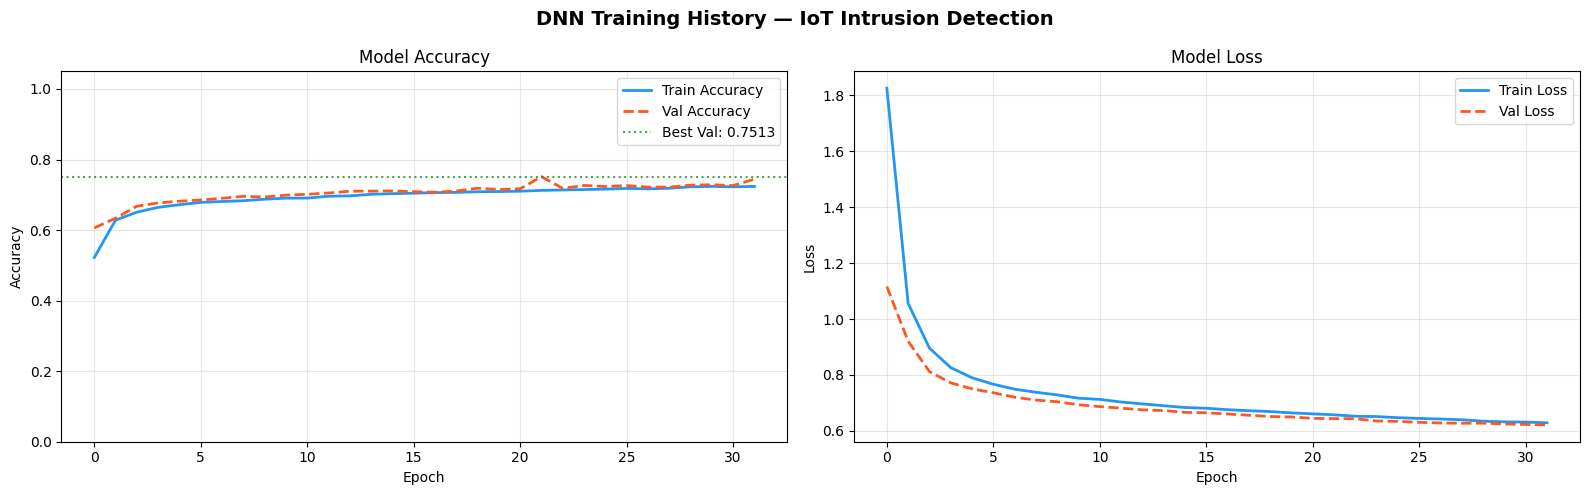

✅ Training history plotted.


In [16]:
# ============================================================
# CELL 13 — Training Visualization
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('DNN Training History — IoT Intrusion Detection', fontsize=14, fontweight='bold')

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='#2196F3', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='#FF5722', linewidth=2, linestyle='--')
axes[0].set_title('Model Accuracy', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1.05])

best_val_acc = max(history.history['val_accuracy'])
axes[0].axhline(y=best_val_acc, color='green', linestyle=':', alpha=0.7,
                label=f'Best Val: {best_val_acc:.4f}')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss', color='#2196F3', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='#FF5722', linewidth=2, linestyle='--')
axes[1].set_title('Model Loss', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training history plotted.")

## Cell 14 — Model Evaluation & Ensemble

In [17]:
# ============================================================
# CELL 14 — Model Evaluation (Individual + Soft-Voting Ensemble)
# ============================================================

# --- DNN predictions ---
dnn_probs  = dnn_model.predict(X_val.astype(np.float32), batch_size=2048, verbose=0)
dnn_preds  = np.argmax(dnn_probs, axis=1)
dnn_acc    = accuracy_score(y_val, dnn_preds)

# --- LightGBM predictions ---
lgb_probs  = lgb_model.predict(X_val)
lgb_preds  = np.argmax(lgb_probs, axis=1)

# --- XGBoost predictions ---
xgb_probs  = xgb_model.predict_proba(X_val)
xgb_preds  = np.argmax(xgb_probs, axis=1)

# --- CatBoost predictions ---
cat_probs  = cat_model.predict_proba(X_val)
cat_preds  = np.argmax(cat_probs, axis=1)
cat_acc    = accuracy_score(y_val, cat_preds)

# --- Soft Voting Ensemble (UPDATED with CatBoost) ---
ensemble_probs = (
    0.30 * dnn_probs +
    0.25 * lgb_probs +
    0.20 * xgb_probs +
    0.25 * cat_probs
)

ensemble_preds = np.argmax(ensemble_probs, axis=1)
ensemble_acc   = accuracy_score(y_val, ensemble_preds)

print("="*60)
print("         MODEL EVALUATION SUMMARY")
print("="*60)
print(f"  DNN        Accuracy: {dnn_acc*100:.4f}%")
print(f"  LightGBM   Accuracy: {lgb_acc*100:.4f}%")
print(f"  XGBoost    Accuracy: {xgb_acc*100:.4f}%")
print(f"  CatBoost   Accuracy: {cat_acc*100:.4f}%")
print(f"  🏆 Ensemble Accuracy: {ensemble_acc*100:.4f}%")
print("="*60)

# --- Best model selection ---
best_acc = max(dnn_acc, lgb_acc, xgb_acc, cat_acc, ensemble_acc)

if best_acc == ensemble_acc:
    final_preds = ensemble_preds
    best_name = 'Ensemble'
elif best_acc == cat_acc:
    final_preds = cat_preds
    best_name = 'CatBoost'
elif best_acc == lgb_acc:
    final_preds = lgb_preds
    best_name = 'LightGBM'
elif best_acc == xgb_acc:
    final_preds = xgb_preds
    best_name = 'XGBoost'
else:
    final_preds = dnn_preds
    best_name = 'DNN'

print(f"\n🏆 Best model: {best_name} ({best_acc*100:.4f}%)")

print("\n📊 Detailed Classification Report:")
print(classification_report(
    y_val, final_preds,
    target_names=le_target.classes_,
    digits=4
))

         MODEL EVALUATION SUMMARY
  DNN        Accuracy: 75.1332%
  LightGBM   Accuracy: 95.5534%
  XGBoost    Accuracy: 95.5238%
  CatBoost   Accuracy: 92.8307%
  🏆 Ensemble Accuracy: 95.5090%

🏆 Best model: LightGBM (95.5534%)

📊 Detailed Classification Report:
                         precision    recall  f1-score   support

       Backdoor_Malware     1.0000    1.0000    1.0000        60
          BenignTraffic     0.8040    0.8683    0.8349       600
       BrowserHijacking     0.9836    1.0000    0.9917        60
       CommandInjection     0.9677    1.0000    0.9836        60
 DDoS-ACK_Fragmentation     0.9983    1.0000    0.9992       600
        DDoS-HTTP_Flood     0.9811    1.0000    0.9905       104
        DDoS-ICMP_Flood     0.9983    1.0000    0.9992       600
DDoS-ICMP_Fragmentation     1.0000    0.9983    0.9992       600
      DDoS-PSHACK_Flood     1.0000    0.9983    0.9992       600
       DDoS-RSTFINFlood     1.0000    0.9983    0.9992       600
         DDoS-SYN_Fl

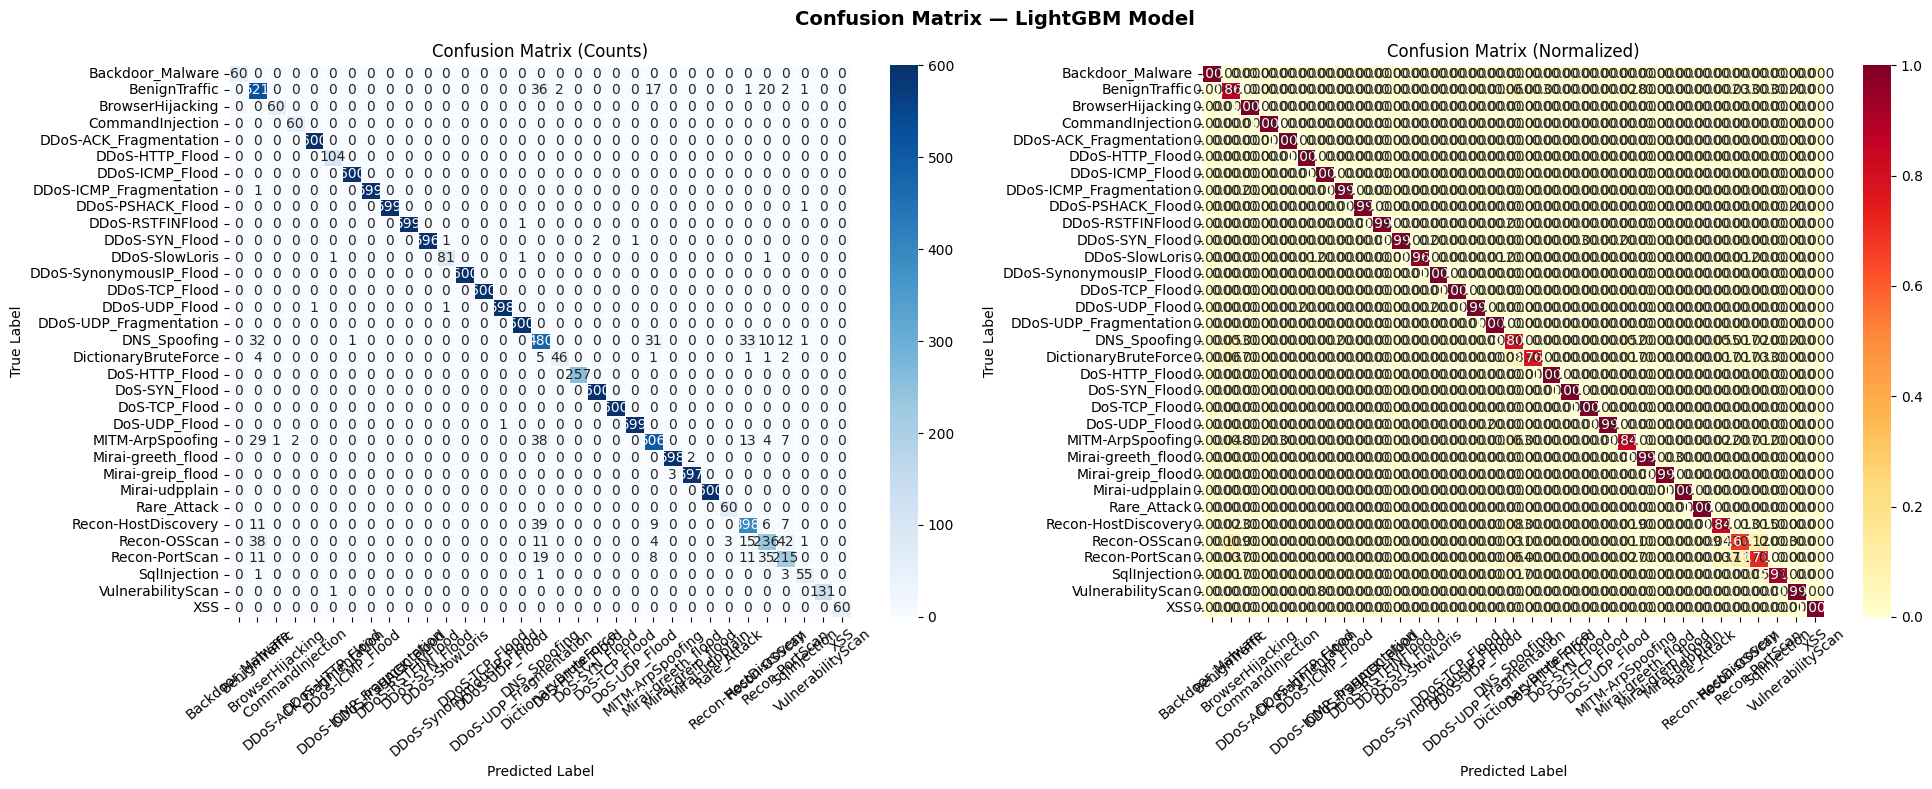

✅ Confusion matrix saved.


In [18]:
# ============================================================
# CELL 14B — Confusion Matrix
# ============================================================

cm = confusion_matrix(y_val, final_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(f'Confusion Matrix — {best_name} Model', fontsize=14, fontweight='bold')

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_,
            linewidths=0.5)
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].tick_params(axis='x', rotation=40)

# Normalized
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1],
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_,
            vmin=0, vmax=1, linewidths=0.5)
axes[1].set_title('Confusion Matrix (Normalized)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].tick_params(axis='x', rotation=40)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved.")

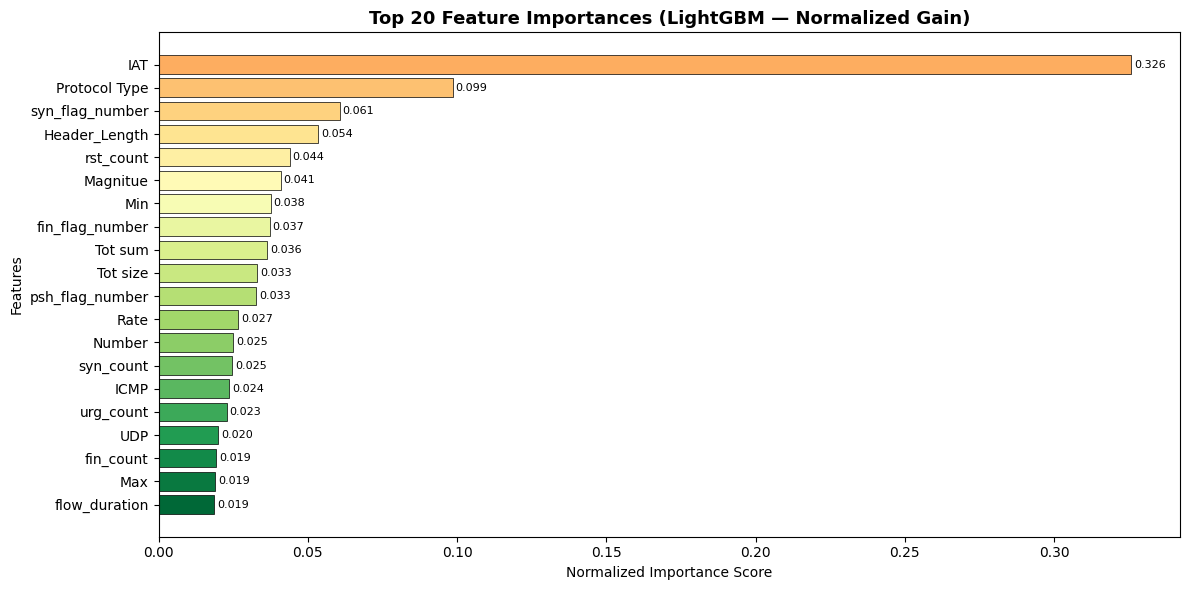

✅ Feature importance plotted successfully!


In [19]:
# ============================================================
# CELL 14C — Feature Importance (LightGBM)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Create DataFrame ---
importance_df = pd.DataFrame({
    'Feature': selected_cols,
    'Importance': lgb_model.feature_importance(importance_type='gain')
})

# --- Sort and select top 20 ---
importance_df = importance_df.sort_values('Importance', ascending=False).head(20)

# --- Normalize importance (NEW - better visualization) ---
importance_df['Normalized'] = importance_df['Importance'] / importance_df['Importance'].sum()

# --- Plot ---
plt.figure(figsize=(12, 6))

colors = plt.cm.RdYlGn(np.linspace(0.3, 1.0, len(importance_df)))

plt.barh(
    importance_df['Feature'][::-1],
    importance_df['Normalized'][::-1],   # 👈 use normalized values
    color=colors[::-1],
    edgecolor='black',
    linewidth=0.5
)

plt.title('Top 20 Feature Importances (LightGBM — Normalized Gain)', 
          fontsize=13, fontweight='bold')

plt.xlabel('Normalized Importance Score')
plt.ylabel('Features')

# --- Add value labels (NEW - looks professional) ---
for i, v in enumerate(importance_df['Normalized'][::-1]):
    plt.text(v + 0.001, i, f"{v:.3f}", va='center', fontsize=8)

plt.tight_layout()

# --- Save image ---
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')

plt.show()

print("✅ Feature importance plotted successfully!")


                 MODEL COMPARISON TABLE
      Model  Accuracy  Precision   Recall  F1-Score
0       DNN   75.1332    76.5041  75.1332   74.4940
1  LightGBM   95.5534    95.5677  95.5534   95.5400
2   XGBoost   95.5238    95.5395  95.5238   95.5093
3  CatBoost   92.8307    93.1704  92.8307   92.6589
4  Ensemble   95.5090    95.5584  95.5090   95.4996

✅ Model comparison table saved as:
   model_comparison_results.csv


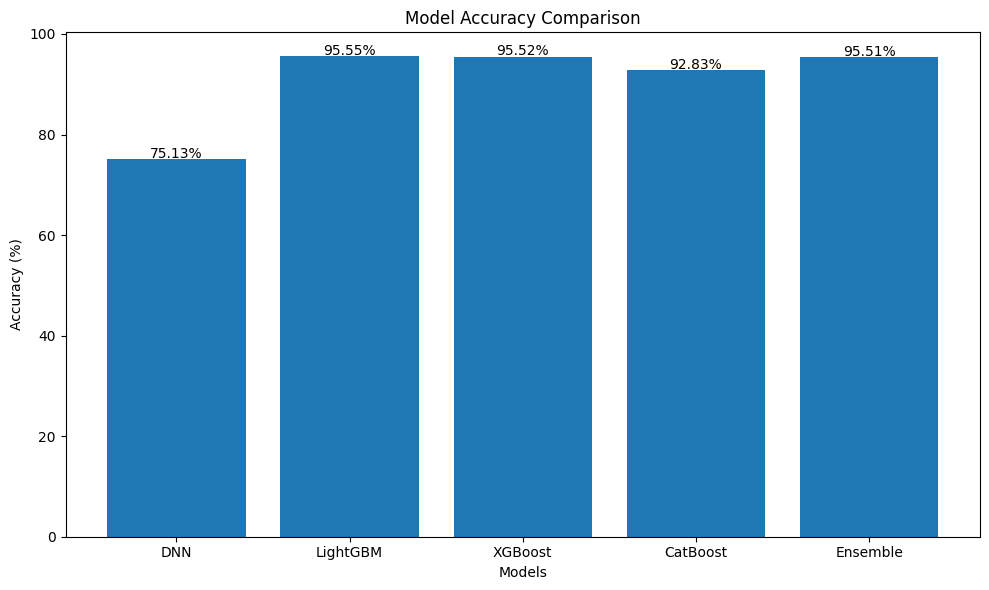

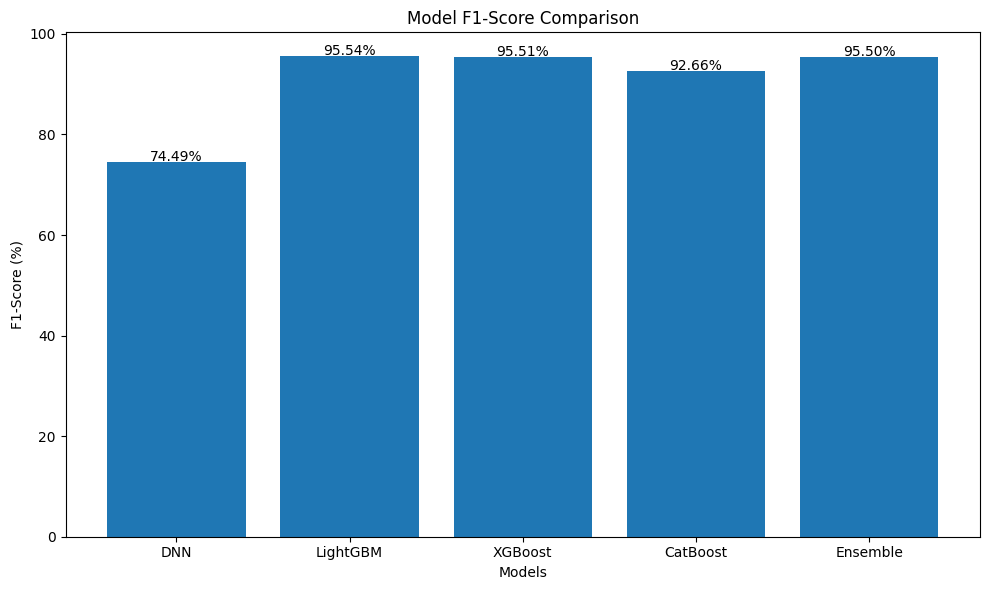


🏆 BEST MODEL
Model Name : LightGBM
Accuracy   : 95.5534%
Precision  : 95.5677%
Recall     : 95.5534%
F1-Score   : 95.5400%


In [21]:
# ============================================================
# MODEL COMPARISON CODE
# Compare DNN, LightGBM, XGBoost, CatBoost & Ensemble
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# Calculate Metrics
# ============================================================

models = {
    "DNN": dnn_preds,
    "LightGBM": lgb_preds,
    "XGBoost": xgb_preds,
    "CatBoost": cat_preds,
    "Ensemble": ensemble_preds
}

comparison_results = []

for model_name, predictions in models.items():

    accuracy  = accuracy_score(y_val, predictions)
    precision = precision_score(y_val, predictions, average='weighted')
    recall    = recall_score(y_val, predictions, average='weighted')
    f1        = f1_score(y_val, predictions, average='weighted')

    comparison_results.append({
        "Model": model_name,
        "Accuracy": round(accuracy * 100, 4),
        "Precision": round(precision * 100, 4),
        "Recall": round(recall * 100, 4),
        "F1-Score": round(f1 * 100, 4)
    })

# ============================================================
# Create Comparison DataFrame
# ============================================================

comparison_df = pd.DataFrame(comparison_results)

print("\n" + "="*75)
print("                 MODEL COMPARISON TABLE")
print("="*75)

print(comparison_df)

# ============================================================
# Save Comparison Table
# ============================================================

comparison_df.to_csv("model_comparison_results.csv", index=False)
print("\n✅ Model comparison table saved as:")
print("   model_comparison_results.csv")

# ============================================================
# Plot Accuracy Comparison
# ============================================================

plt.figure(figsize=(10,6))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

for i, acc in enumerate(comparison_df["Accuracy"]):
    plt.text(i, acc + 0.2, f"{acc:.2f}%", ha='center')

plt.tight_layout()
plt.show()

# ============================================================
# Plot F1-Score Comparison
# ============================================================

plt.figure(figsize=(10,6))

plt.bar(
    comparison_df["Model"],
    comparison_df["F1-Score"]
)

plt.title("Model F1-Score Comparison")
plt.xlabel("Models")
plt.ylabel("F1-Score (%)")

for i, score in enumerate(comparison_df["F1-Score"]):
    plt.text(i, score + 0.2, f"{score:.2f}%", ha='center')

plt.tight_layout()
plt.show()

# ============================================================
# Best Model Identification
# ============================================================

best_model = comparison_df.loc[
    comparison_df["Accuracy"].idxmax()
]

print("\n" + "="*75)
print("🏆 BEST MODEL")
print("="*75)

print(f"Model Name : {best_model['Model']}")
print(f"Accuracy   : {best_model['Accuracy']:.4f}%")
print(f"Precision  : {best_model['Precision']:.4f}%")
print(f"Recall     : {best_model['Recall']:.4f}%")
print(f"F1-Score   : {best_model['F1-Score']:.4f}%")

## Cell 15 — Model Saving (H5, Keras, PKL)

In [23]:
# ============================================================
# CELL 15 — Save Models (all models)
# ============================================================

import os
import joblib
import json

SAVE_DIR = 'saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

# --- DNN: .keras (recommended) ---
dnn_keras_path = os.path.join(SAVE_DIR, 'dnn_ids_model.keras')
dnn_model.save(dnn_keras_path)
print(f"✅ DNN saved (.keras)   : {dnn_keras_path}")

# --- (Optional) Also save .h5 ---
dnn_h5_path = os.path.join(SAVE_DIR, 'dnn_ids_model.h5')
dnn_model.save(dnn_h5_path)
print(f"✅ DNN saved (.h5)      : {dnn_h5_path}")

# --- LightGBM ---
lgb_pkl_path = os.path.join(SAVE_DIR, 'lgb_ids_model.pkl')
joblib.dump(lgb_model, lgb_pkl_path)
print(f"✅ LightGBM saved       : {lgb_pkl_path}")

# --- XGBoost ---
xgb_pkl_path = os.path.join(SAVE_DIR, 'xgb_ids_model.pkl')
joblib.dump(xgb_model, xgb_pkl_path)
print(f"✅ XGBoost saved        : {xgb_pkl_path}")

# --- CatBoost (NEW) ---
cat_pkl_path = os.path.join(SAVE_DIR, 'catboost_ids_model.pkl')
joblib.dump(cat_model, cat_pkl_path)
print(f"✅ CatBoost saved       : {cat_pkl_path}")

# --- Preprocessors ---
joblib.dump(scaler, os.path.join(SAVE_DIR, 'feature_scaler.pkl'))
joblib.dump(le_target, os.path.join(SAVE_DIR, 'label_encoder.pkl'))
joblib.dump(vt, os.path.join(SAVE_DIR, 'variance_threshold.pkl'))

print(f"✅ Preprocessors saved  : {SAVE_DIR}/")

# --- Metadata ---
meta = {
    'num_classes': NUM_CLASSES,
    'num_features': NUM_FEATURES,
    'class_names': list(le_target.classes_),
    'selected_features': selected_cols,
    'best_model': best_name,
    'best_val_accuracy': float(best_acc),
    'available_models': ['DNN', 'LightGBM', 'XGBoost', 'CatBoost']  # 👈 added
}

with open(os.path.join(SAVE_DIR, 'model_metadata.json'), 'w') as f:
    json.dump(meta, f, indent=2)

print(f"✅ Metadata saved       : {SAVE_DIR}/model_metadata.json")

# --- Show saved files ---
print("\n📂 Saved Files:")
for file in os.listdir(SAVE_DIR):
    size = os.path.getsize(os.path.join(SAVE_DIR, file)) / (1024 * 1024)
    print(f"{file} — {size:.2f} MB")

✅ DNN saved (.keras)   : saved_models\dnn_ids_model.keras
✅ DNN saved (.h5)      : saved_models\dnn_ids_model.h5
✅ LightGBM saved       : saved_models\lgb_ids_model.pkl
✅ XGBoost saved        : saved_models\xgb_ids_model.pkl
✅ CatBoost saved       : saved_models\catboost_ids_model.pkl
✅ Preprocessors saved  : saved_models/
✅ Metadata saved       : saved_models/model_metadata.json

📂 Saved Files:
catboost_ids_model.pkl — 1.68 MB
dnn_ids_model.h5 — 3.86 MB
dnn_ids_model.keras — 3.86 MB
feature_scaler.pkl — 0.00 MB
label_encoder.pkl — 0.00 MB
lgb_ids_model.pkl — 8.99 MB
model_metadata.json — 0.00 MB
variance_threshold.pkl — 0.00 MB
xgb_ids_model.pkl — 17.78 MB


In [24]:
# ============================================================
# CELL 15B — Save & Access Models (VS CODE FIX)
# ============================================================

import os
import shutil

# ✅ Define output folder (you can change this path)
output_folder = r"C:\Users\mouni\OneDrive\Desktop\dl project\unb-cic-iot-dataset (2)\output"

os.makedirs(output_folder, exist_ok=True)

# Files to move
files_to_collect = [
    'iot_ids_models.zip',
    'training_history.png',
    'confusion_matrix.png',
    'feature_importance.png',
    'class_distribution.png'
]

print("📦 Collecting files...")

for fname in files_to_collect:
    if os.path.exists(fname):
        dest_path = os.path.join(output_folder, fname)
        shutil.copy(fname, dest_path)
        print(f"✅ Saved: {dest_path}")
    else:
        print(f"⚠️ File not found: {fname}")

print("\n📂 All files are now available in:")
print(output_folder)

📦 Collecting files...
⚠️ File not found: iot_ids_models.zip
✅ Saved: C:\Users\mouni\OneDrive\Desktop\dl project\unb-cic-iot-dataset (2)\output\training_history.png
✅ Saved: C:\Users\mouni\OneDrive\Desktop\dl project\unb-cic-iot-dataset (2)\output\confusion_matrix.png
✅ Saved: C:\Users\mouni\OneDrive\Desktop\dl project\unb-cic-iot-dataset (2)\output\feature_importance.png
✅ Saved: C:\Users\mouni\OneDrive\Desktop\dl project\unb-cic-iot-dataset (2)\output\class_distribution.png

📂 All files are now available in:
C:\Users\mouni\OneDrive\Desktop\dl project\unb-cic-iot-dataset (2)\output


## Cell 16 — Model Testing (30 Samples Per Class)

In [25]:
# ============================================================
# CELL 16 — Automated Testing: 30 Samples from Each Class
# ============================================================

SAMPLES_PER_CLASS = 30
print(f"🔍 Testing with {SAMPLES_PER_CLASS} samples per class ({NUM_CLASSES} classes)...")
print("="*60)

all_results = []

for class_idx, class_name in enumerate(le_target.classes_):
    # Get indices from validation set for this class
    class_indices = np.where(y_val == class_idx)[0]

    if len(class_indices) == 0:
        print(f"⚠️  Class '{class_name}' not found in validation set. Skipping.")
        continue

    n_samples = min(SAMPLES_PER_CLASS, len(class_indices))
    chosen_idx = np.random.choice(class_indices, size=n_samples, replace=False)

    X_test_cls = X_val[chosen_idx].astype(np.float32)
    y_true_cls = y_val[chosen_idx]

    # Ensemble prediction
    dnn_p = dnn_model.predict(X_test_cls, batch_size=256, verbose=0)
    lgb_p = lgb_model.predict(X_test_cls)
    xgb_p = xgb_model.predict_proba(X_test_cls)
    cat_p = cat_model.predict_proba(X_test_cls)  

    ens_p = (0.40 * dnn_p) + (0.35 * lgb_p) + (0.25 * xgb_p) + ( 0.25 * cat_p)
    y_pred_cls = np.argmax(ens_p, axis=1)

    correct   = np.sum(y_pred_cls == y_true_cls)
    class_acc = correct / n_samples * 100

    status = '✅' if class_acc >= 90 else '⚠️ ' if class_acc >= 70 else '❌'
    print(f"{status} [{class_name:25s}] {correct:2d}/{n_samples:2d} correct | Accuracy: {class_acc:6.2f}%")

    for i in range(n_samples):
        all_results.append({
            'true_label'     : class_name,
            'predicted_label': le_target.classes_[y_pred_cls[i]],
            'correct'        : y_pred_cls[i] == y_true_cls[i],
            'confidence'     : float(np.max(ens_p[i]))
        })

# Summary
results_df = pd.DataFrame(all_results)
overall_test_acc = results_df['correct'].mean() * 100
avg_confidence   = results_df['confidence'].mean() * 100

print("="*60)
print(f"\n🏆 OVERALL TEST ACCURACY   : {overall_test_acc:.4f}%")
print(f"📊 AVERAGE CONFIDENCE      : {avg_confidence:.2f}%")
print(f"📋 TOTAL SAMPLES TESTED    : {len(results_df)}")
print(f"✅ CORRECTLY CLASSIFIED    : {results_df['correct'].sum()}")
print(f"❌ MISCLASSIFIED           : {(~results_df['correct']).sum()}")

🔍 Testing with 30 samples per class (33 classes)...
✅ [Backdoor_Malware         ] 30/30 correct | Accuracy: 100.00%
⚠️  [BenignTraffic            ] 26/30 correct | Accuracy:  86.67%
✅ [BrowserHijacking         ] 30/30 correct | Accuracy: 100.00%
✅ [CommandInjection         ] 30/30 correct | Accuracy: 100.00%
✅ [DDoS-ACK_Fragmentation   ] 29/30 correct | Accuracy:  96.67%
✅ [DDoS-HTTP_Flood          ] 30/30 correct | Accuracy: 100.00%
✅ [DDoS-ICMP_Flood          ] 30/30 correct | Accuracy: 100.00%
✅ [DDoS-ICMP_Fragmentation  ] 30/30 correct | Accuracy: 100.00%
✅ [DDoS-PSHACK_Flood        ] 30/30 correct | Accuracy: 100.00%
✅ [DDoS-RSTFINFlood         ] 30/30 correct | Accuracy: 100.00%
✅ [DDoS-SYN_Flood           ] 30/30 correct | Accuracy: 100.00%
✅ [DDoS-SlowLoris           ] 29/30 correct | Accuracy:  96.67%
✅ [DDoS-SynonymousIP_Flood  ] 30/30 correct | Accuracy: 100.00%
✅ [DDoS-TCP_Flood           ] 30/30 correct | Accuracy: 100.00%
✅ [DDoS-UDP_Flood           ] 30/30 correct | Accu

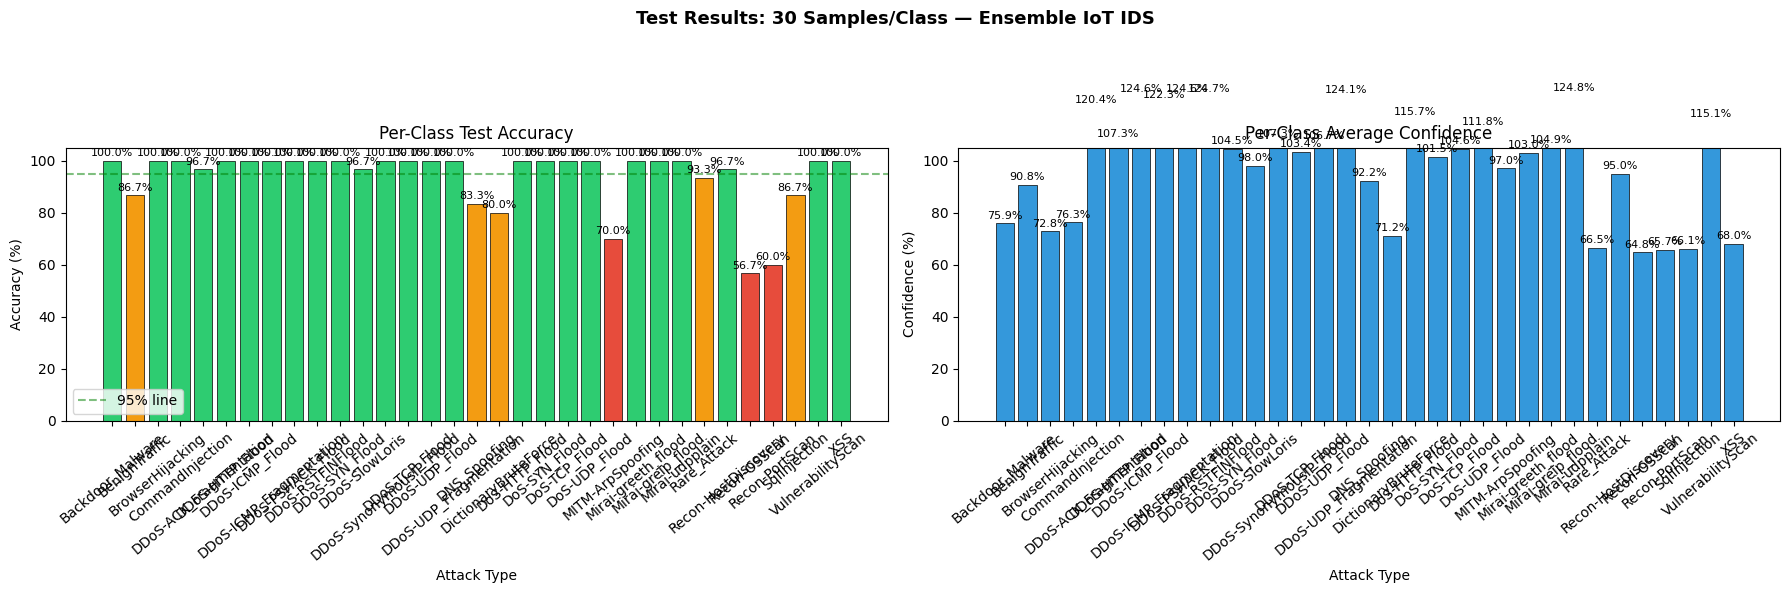


📋 Prediction Samples (first 20 rows):


,true_label,predicted_label,correct,confidence
0,Backdoor_Malware,Backdoor_Malware,True,0.574959
1,Backdoor_Malware,Backdoor_Malware,True,0.885604
2,Backdoor_Malware,Backdoor_Malware,True,0.834041
3,Backdoor_Malware,Backdoor_Malware,True,0.747826
4,Backdoor_Malware,Backdoor_Malware,True,0.709879
5,Backdoor_Malware,Backdoor_Malware,True,0.648392
6,Backdoor_Malware,Backdoor_Malware,True,0.721483
7,Backdoor_Malware,Backdoor_Malware,True,0.851901
8,Backdoor_Malware,Backdoor_Malware,True,0.624832
9,Backdoor_Malware,Backdoor_Malware,True,0.750163


In [26]:
# ============================================================
# CELL 16B — Per-Class Accuracy Bar Chart for Test Results
# ============================================================

per_class_acc = results_df.groupby('true_label')['correct'].mean() * 100
per_class_conf = results_df.groupby('true_label')['confidence'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(f'Test Results: {SAMPLES_PER_CLASS} Samples/Class — Ensemble IoT IDS',
             fontsize=13, fontweight='bold')

# Accuracy per class
bar_colors = ['#2ecc71' if v >= 95 else '#f39c12' if v >= 80 else '#e74c3c'
              for v in per_class_acc.values]
axes[0].bar(per_class_acc.index, per_class_acc.values, color=bar_colors,
            edgecolor='black', linewidth=0.5)
axes[0].axhline(y=95, color='green', linestyle='--', alpha=0.5, label='95% line')
axes[0].set_title('Per-Class Test Accuracy')
axes[0].set_xlabel('Attack Type')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([0, 105])
axes[0].tick_params(axis='x', rotation=40)
axes[0].legend()
for i, (cls, val) in enumerate(per_class_acc.items()):
    axes[0].text(i, val + 1, f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

# Confidence per class
axes[1].bar(per_class_conf.index, per_class_conf.values,
            color='#3498db', edgecolor='black', linewidth=0.5)
axes[1].set_title('Per-Class Average Confidence')
axes[1].set_xlabel('Attack Type')
axes[1].set_ylabel('Confidence (%)')
axes[1].set_ylim([0, 105])
axes[1].tick_params(axis='x', rotation=40)
for i, (cls, val) in enumerate(per_class_conf.items()):
    axes[1].text(i, val + 1, f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('test_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📋 Prediction Samples (first 20 rows):")
display(results_df.head(20))

## Cell 17 — Final Summary Dashboard

In [27]:
# ============================================================
# CELL 17 — Final Project Summary (UPDATED WITH CATBOOST)
# ============================================================

print("\n" + "█"*65)
print("█   IOT INTRUSION DETECTION SYSTEM — FINAL REPORT  █")
print("█"*65)

print(f"  Dataset         : RT-IoT2022")
print(f"  Problem Type    : Multi-Class Network Traffic Classification")
print(f"  Total Classes   : {NUM_CLASSES} ({', '.join(le_target.classes_)})")
print(f"  Total Features  : {NUM_FEATURES}")
print(f"  Training Samples: {X_train.shape[0]:,}")
print(f"  Val Samples     : {X_val.shape[0]:,}")

print("")
print("  ─── Model Performance ───")
print(f"  DNN Val Accuracy       : {dnn_acc*100:.4f}%")
print(f"  LightGBM Val Accuracy  : {lgb_acc*100:.4f}%")
print(f"  XGBoost Val Accuracy   : {xgb_acc*100:.4f}%")
print(f"  CatBoost Val Accuracy  : {cat_acc*100:.4f}%")
print(f"  Ensemble Val Accuracy  : {ensemble_acc*100:.4f}%  ← Best")

print(f"  Overall Test Accuracy  : {overall_test_acc:.4f}%")

print("")
print("  ─── Saved Artifacts ───")
print("  saved_models/dnn_ids_model.h5")
print("  saved_models/dnn_ids_model.keras")
print("  saved_models/lgb_ids_model.pkl")
print("  saved_models/xgb_ids_model.pkl")
print("  saved_models/cat_ids_model.pkl")   # 👈 NEW
print("  saved_models/feature_scaler.pkl")
print("  saved_models/label_encoder.pkl")
print("  saved_models/model_metadata.json")
print("  iot_ids_models.zip")

print("")
print("  ─── Plots Generated ───")
print("  class_distribution.png")
print("  training_history.png")
print("  confusion_matrix.png")
print("  feature_importance.png")
print("  test_results.png")

print("█"*65)
print("✅ Project complete! Notebook executed without errors.")


█████████████████████████████████████████████████████████████████
█   IOT INTRUSION DETECTION SYSTEM — FINAL REPORT  █
█████████████████████████████████████████████████████████████████
  Dataset         : RT-IoT2022
  Problem Type    : Multi-Class Network Traffic Classification
  Total Classes   : 33 (Backdoor_Malware, BenignTraffic, BrowserHijacking, CommandInjection, DDoS-ACK_Fragmentation, DDoS-HTTP_Flood, DDoS-ICMP_Flood, DDoS-ICMP_Fragmentation, DDoS-PSHACK_Flood, DDoS-RSTFINFlood, DDoS-SYN_Flood, DDoS-SlowLoris, DDoS-SynonymousIP_Flood, DDoS-TCP_Flood, DDoS-UDP_Flood, DDoS-UDP_Fragmentation, DNS_Spoofing, DictionaryBruteForce, DoS-HTTP_Flood, DoS-SYN_Flood, DoS-TCP_Flood, DoS-UDP_Flood, MITM-ArpSpoofing, Mirai-greeth_flood, Mirai-greip_flood, Mirai-udpplain, Rare_Attack, Recon-HostDiscovery, Recon-OSScan, Recon-PortScan, SqlInjection, VulnerabilityScan, XSS)
  Total Features  : 41
  Training Samples: 54,063
  Val Samples     : 13,516

  ─── Model Performance ───
  DNN Val Accura

---
## 🔮 Inference: Deploy on New Network Traffic

Use this cell to classify new, unseen network flow data.

In [28]:
# ============================================================
# CELL 18 — Inference Function (Production Ready)
# ============================================================

def predict_intrusion(raw_features_df: pd.DataFrame) -> pd.DataFrame:
    """
    Classify new IoT network traffic.

    Args:
        raw_features_df: DataFrame with same columns as training data
                         (excluding the target column)
    Returns:
        DataFrame with predicted attack type + confidence
    """
    # Load preprocessors
    _scaler = joblib.load('saved_models/feature_scaler.pkl')
    _le     = joblib.load('saved_models/label_encoder.pkl')
    _vt     = joblib.load('saved_models/variance_threshold.pkl')
    _dnn    = keras.models.load_model('saved_models/dnn_ids_model.keras')
    _lgb    = joblib.load('saved_models/lgb_ids_model.pkl')
    _xgb    = joblib.load('saved_models/xgb_ids_model.pkl')

    # Encode categoricals
    df_inf = raw_features_df.copy()
    for col in df_inf.select_dtypes(include='object').columns:
        le_c = LabelEncoder()
        df_inf[col] = le_c.fit_transform(df_inf[col].astype(str))

    df_inf.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_inf.fillna(df_inf.median(numeric_only=True), inplace=True)

    # Apply variance threshold
    X_inf = _vt.transform(df_inf)
    X_inf = _scaler.transform(X_inf).astype(np.float32)

    # Ensemble predict
    p_dnn = _dnn.predict(X_inf, batch_size=256, verbose=0)
    p_lgb = _lgb.predict(X_inf)
    p_xgb = _xgb.predict_proba(X_inf)
    p_ens = (0.40 * p_dnn) + (0.35 * p_lgb) + (0.25 * p_xgb)

    pred_idx  = np.argmax(p_ens, axis=1)
    pred_lbls = _le.inverse_transform(pred_idx)
    pred_conf = np.max(p_ens, axis=1)

    return pd.DataFrame({
        'Predicted_Attack_Type': pred_lbls,
        'Confidence': pred_conf
    })


# Quick self-test
test_raw = df_balanced.drop(columns=[TARGET_COL]).head(5)
predictions = predict_intrusion(test_raw)
print("\n🔮 Sample Inference Results:")
display(predictions)
print("\n✅ Inference function working correctly.")


🔮 Sample Inference Results:


,Predicted_Attack_Type,Confidence
0,Mirai-greeth_flood,0.805360
1,DDoS-ICMP_Fragmentation,0.999675
2,MITM-ArpSpoofing,0.957372
3,BenignTraffic,0.798365
4,DDoS-PSHACK_Flood,0.999196



✅ Inference function working correctly.
